# Reconstructed spectra and peak-level errors (axis-200-900)

Individual spectra make the population statistics concrete: the best, the worst and fixed random pixels of every population are shown with their reconstruction in full and zoomed on single peaks, so that the peak shape (envelope) produced by the decoder can be judged, together with the window decomposition of their cost and peak-level errors.

## Introduction

A global cost cannot tell whether the decoder reproduces individual peaks or only a smoothed envelope of the
spectrum. Zooming on the strongest peak shows the shape at the resolution of the axis; zooming on the window
with the largest contribution to $W_1$ shows where the cost of the spectrum is paid. Peak-level matching then
separates two failure modes that $W_1$ mixes: a peak at the wrong m/z (position error) and a peak at the right
m/z with the wrong abundance (intensity error).

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

        * Fixed cases are drawn uniformly (seed 42, six per population, identical for every model). Best and worst cases
          are the six pixels with the smallest and the largest $W_1$ of each model and are therefore model-specific;
          they are extremes, not representative pixels.
        * Spectra are shown for the representative model of the axis (next section); case windows and peak errors are
          pooled over all repetitions.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

        * Peak: local maximum of the input with prominence at least 2 % of the spectrum maximum; its match is the
          reconstruction maximum within +/- 5 bins.
        * Zoom: +/- `spectrum_zoom.half_width` m/z (15) around the strongest input peak; largest-contribution window:
          the 100 Da window with the largest $C_W$ of the spectrum.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "reconstruction_spectra"
AXIS = "axis-200-900"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

cases = table('cases')
case_windows = table('case_windows')
REPRESENTATIVE = metadata['representative_model']
ZOOM = float(metadata['zoom_half_width'])
own_windows = case_windows[case_windows.model_id == REPRESENTATIVE]


def worst_windows(keys):
    """Largest-contribution window of every displayed case of the representative model."""
    result = {}
    for population, row in keys:
        frame = own_windows[(own_windows.population == population) & (own_windows.row == row)]
        top = frame.loc[frame.contribution.idxmax()]
        result[(population, row)] = (top.window_label, top.window_lower, top.window_upper)
    return result


def show_cases(kind, ascending):
    """Two cases of one kind per population, one zoom figure per population."""
    for population in POPULATIONS:
        rows = cases[(cases.population == population) & (cases.case_kind == kind)].drop_duplicates('row')
        keys = [(population, int(row)) for row in rows.sort_values('masserstein', ascending=ascending).row.head(2)]
        if keys:
            figures.spectrum_zoom(cases, keys=keys, half_width=ZOOM, worst_windows=worst_windows(keys), theme=theme)
            plt.show()
print('Representative model:', REPRESENTATIVE)

Analysis: reconstruction_spectra | axis: axis-200-900 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 200-900 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


Representative model: metaspace-pretrain-repaired-20260923-01__grid_0000__rep_02__real_only


## Producing the tables this notebook reads

### Methodology

#### Implementation

The `inference` level stores the input and reconstruction of the fixed, best and worst rows of every model;
`reconstruction_spectra` joins their identities and window decomposition and runs peak matching on them.
Spectra are exported for the representative model only.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis reconstruction_spectra > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis         repetition model_id                                                                                                                                                      
axis-200-900 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6970  0.4851       3.2834                   0.8835          0.9449        3.0           False
             1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6899  0.4772       2.9758                   0.8751          1.0732        4.2           False
             2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6990  0.5055       3.1069                   0.8918          0.9337        1.4            True
             3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6947  0.4789       3.1123                   0.9003          0.9509        3.2           False
             4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6957  0.4872       3.1081                   0.8833          0.9554        3.2           False

### Remarks

- Representative model: repetition 2 (mean rank 1.4 of 5): best macro AP (0.699), F1 (0.506) and spectral angle (0.934); repetition 1 has the lowest $W_1$ (2.98) but the worst angle and AP, so no repetition wins every metric.

### Notes

## Best reconstructed spectra per population

### Methodology

#### Theoretical

The best cases show the attainable quality: whether even these spectra keep the peak shape or are smoothed.

#### Implementation

Two `best` cases per population of the representative model; the largest-contribution window comes from `case_windows`.

#### Figure descriptions

One figure per population, two cases each (pairs of rows). Columns: full m/z range, zoom on the strongest
input peak, zoom on the window with the largest contribution to $W_1$. Top of each pair: grey = input,
colour = reconstruction (colour = population); bottom: signed residual (reconstruction - input). Zoom
limits are set from the values inside the zoom. Titles give population, row, case kind and $W_1$.

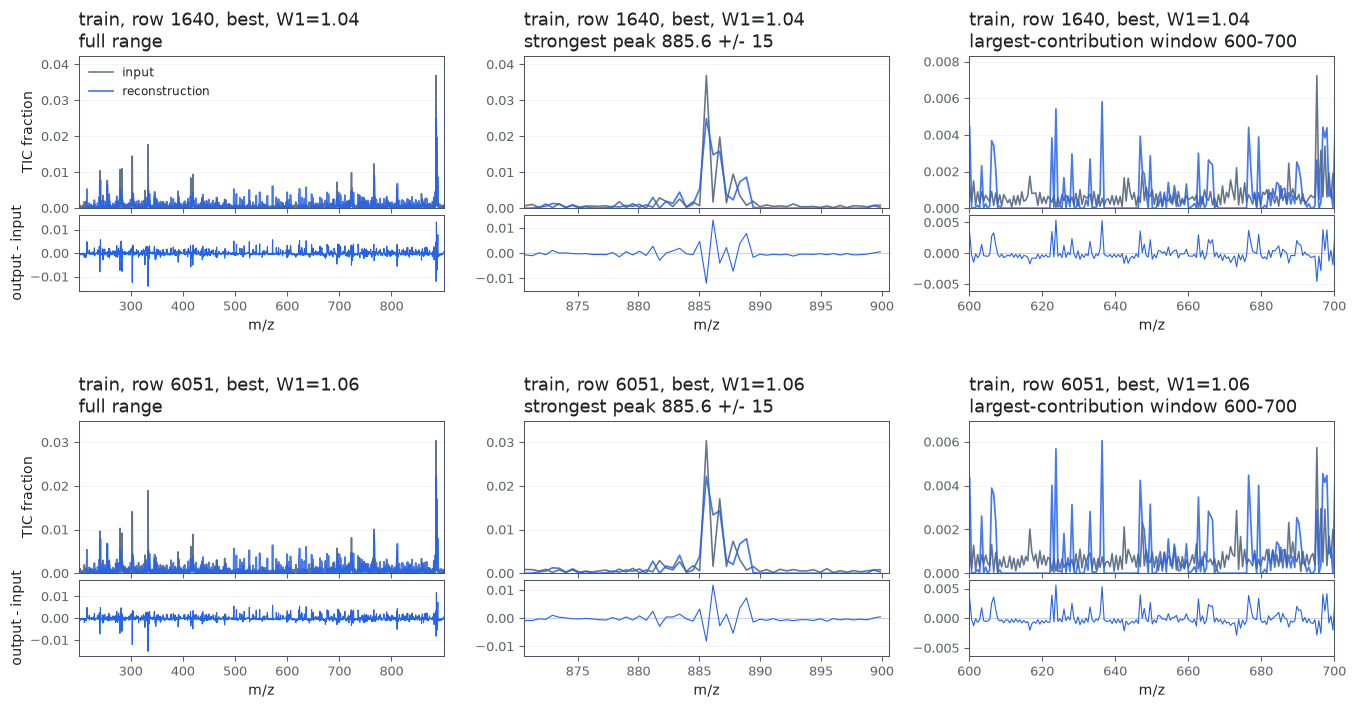

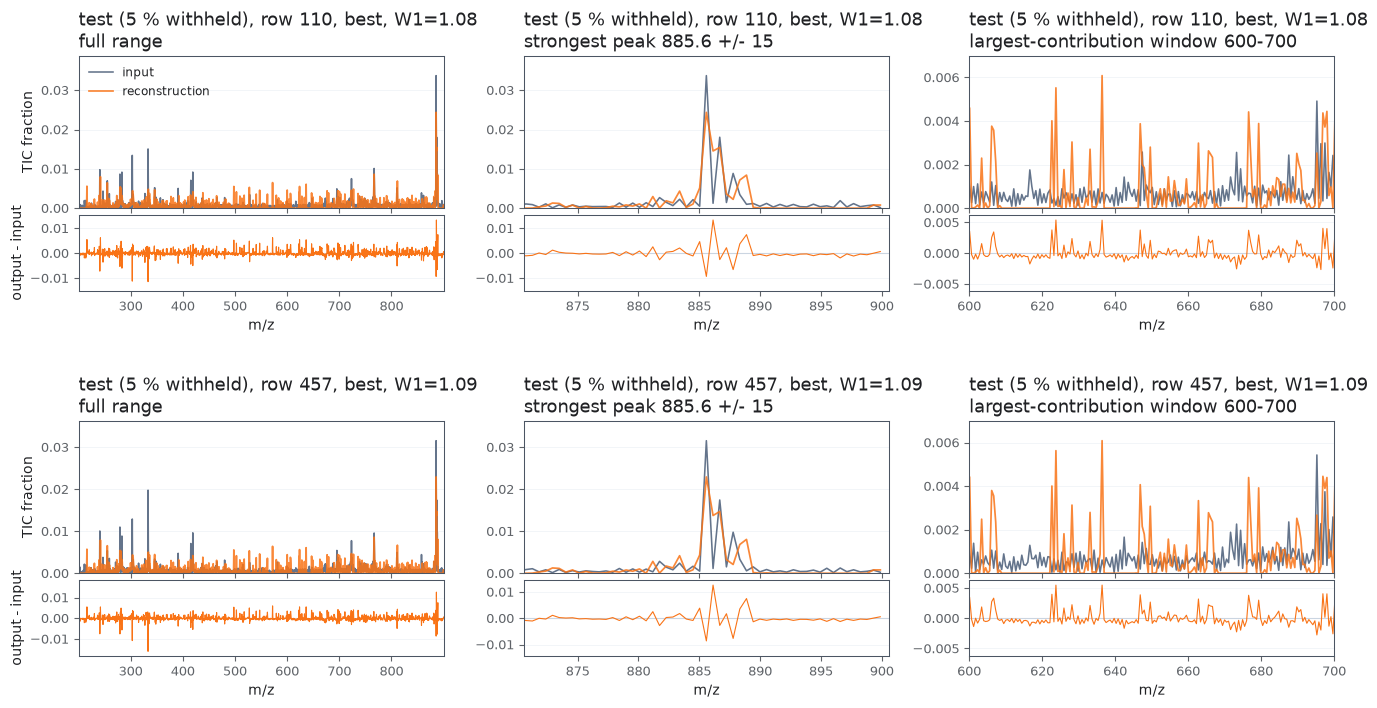

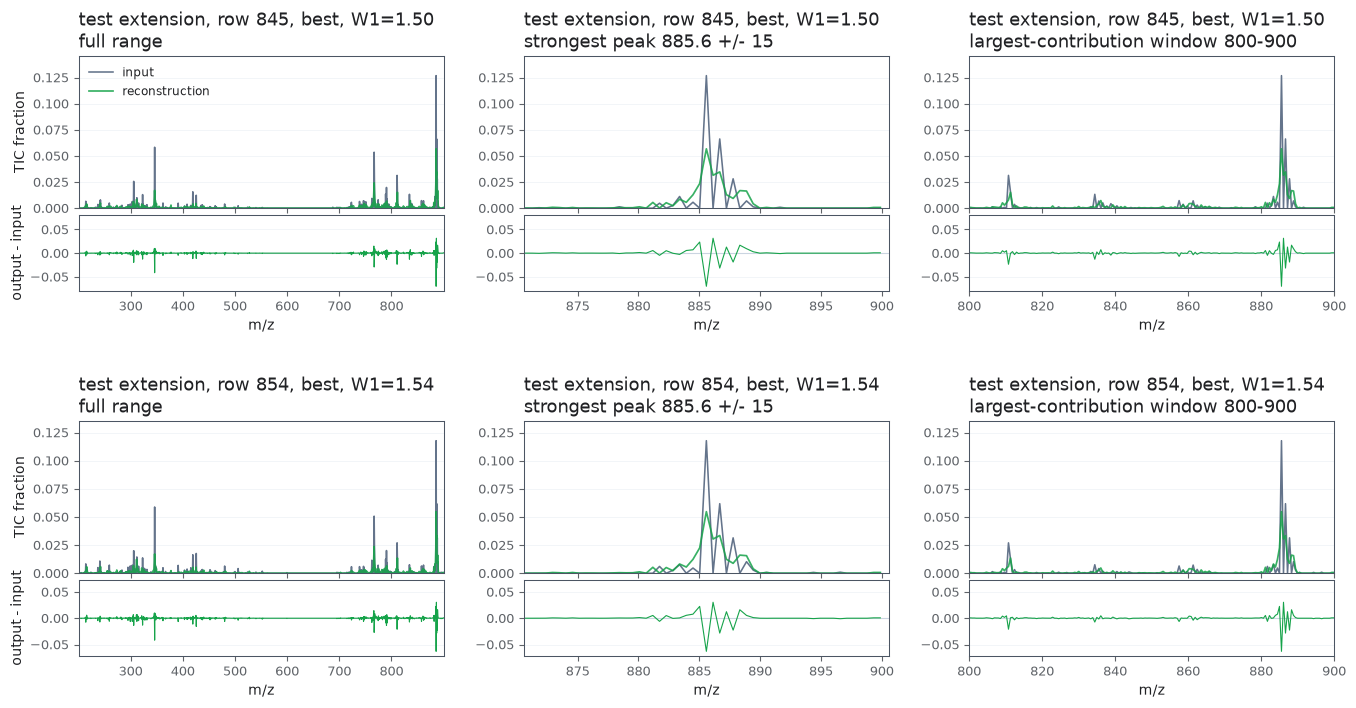

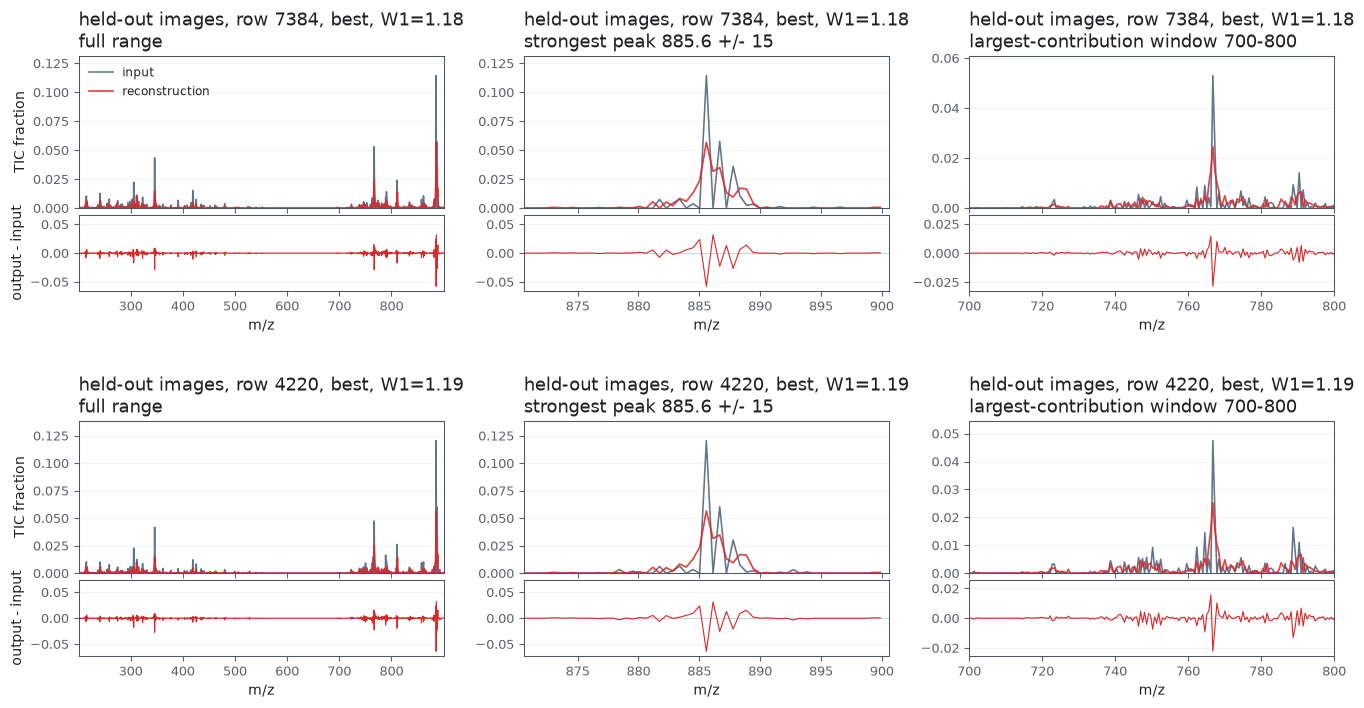

In [4]:
show_cases('best', ascending=True)

### Remarks

- Best cases reach $W_1$ 1.1-1.2 on every population; their largest-contribution window is mostly 800-900 or 600-700 m/z.
- Even here the zoom shows the reconstructed peak lower and wider than the input peak: the decoder draws an envelope around the peak rather than the peak itself.

### Notes

## Worst reconstructed spectra per population

### Methodology

#### Theoretical

The worst cases show how a failed reconstruction looks: missing peaks, moved intensity or a wrong envelope.

#### Implementation

Two `worst` cases per population of the representative model; the largest-contribution window comes from `case_windows`.

#### Figure descriptions

One figure per population, two cases each (pairs of rows). Columns: full m/z range, zoom on the strongest
input peak, zoom on the window with the largest contribution to $W_1$. Top of each pair: grey = input,
colour = reconstruction (colour = population); bottom: signed residual (reconstruction - input). Zoom
limits are set from the values inside the zoom. Titles give population, row, case kind and $W_1$.

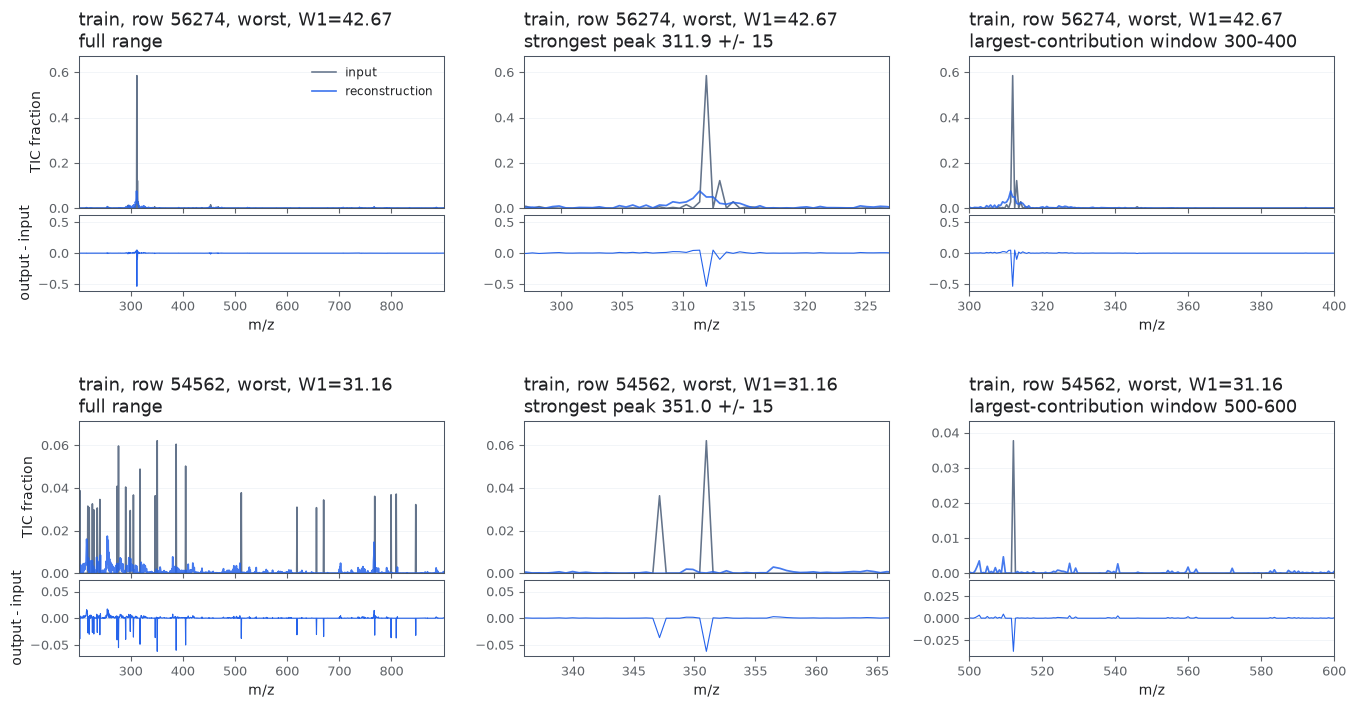

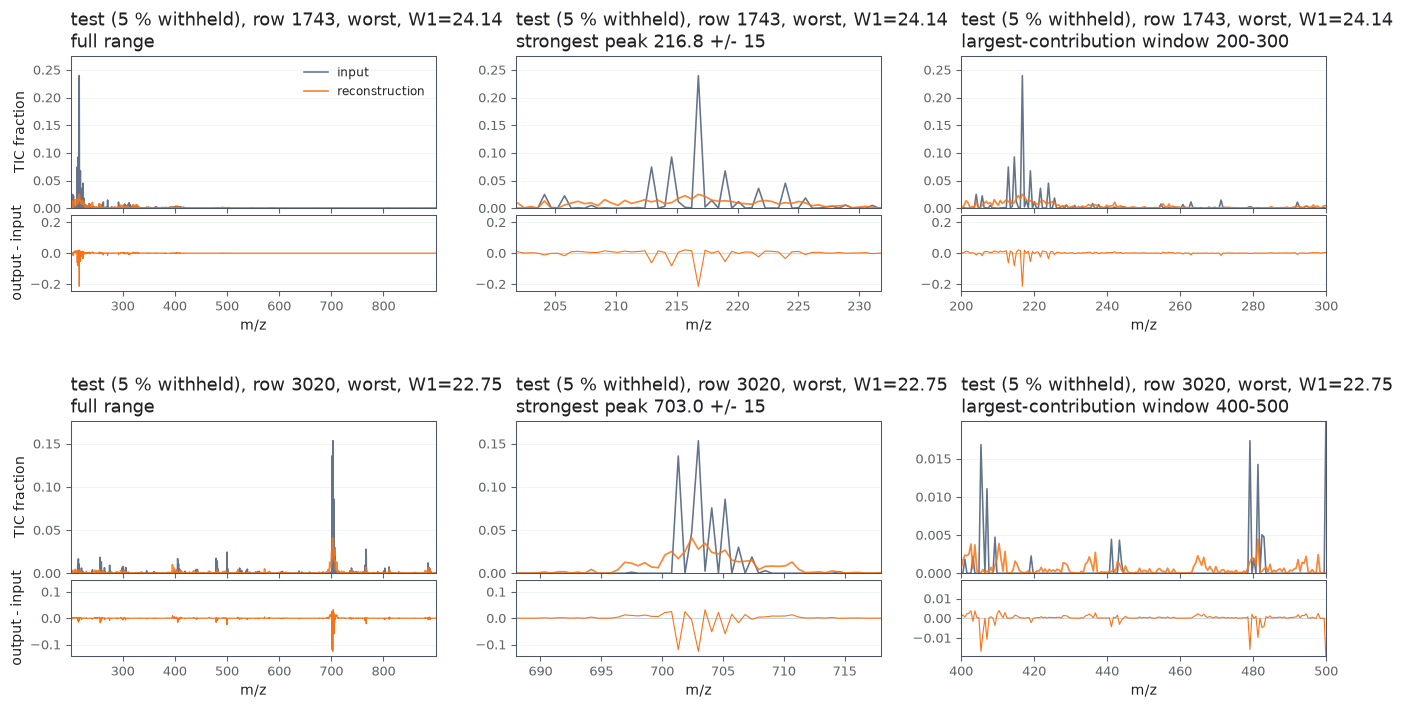

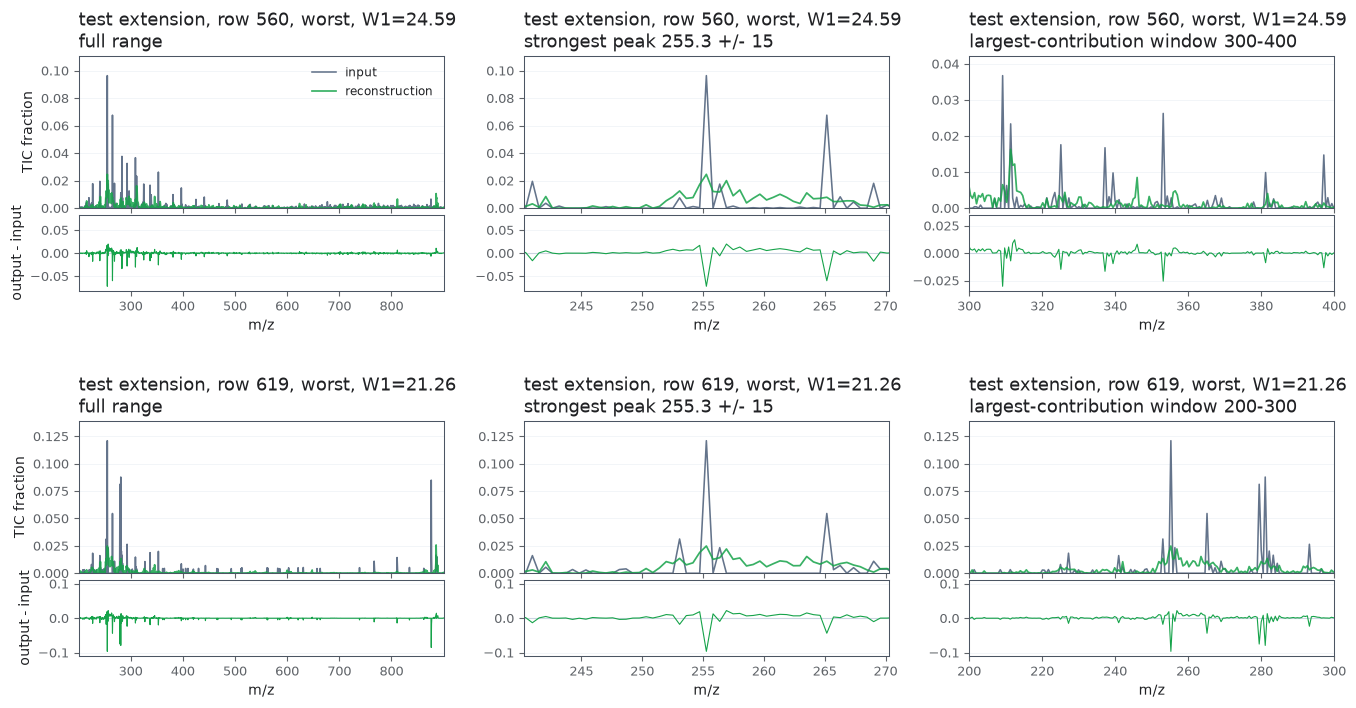

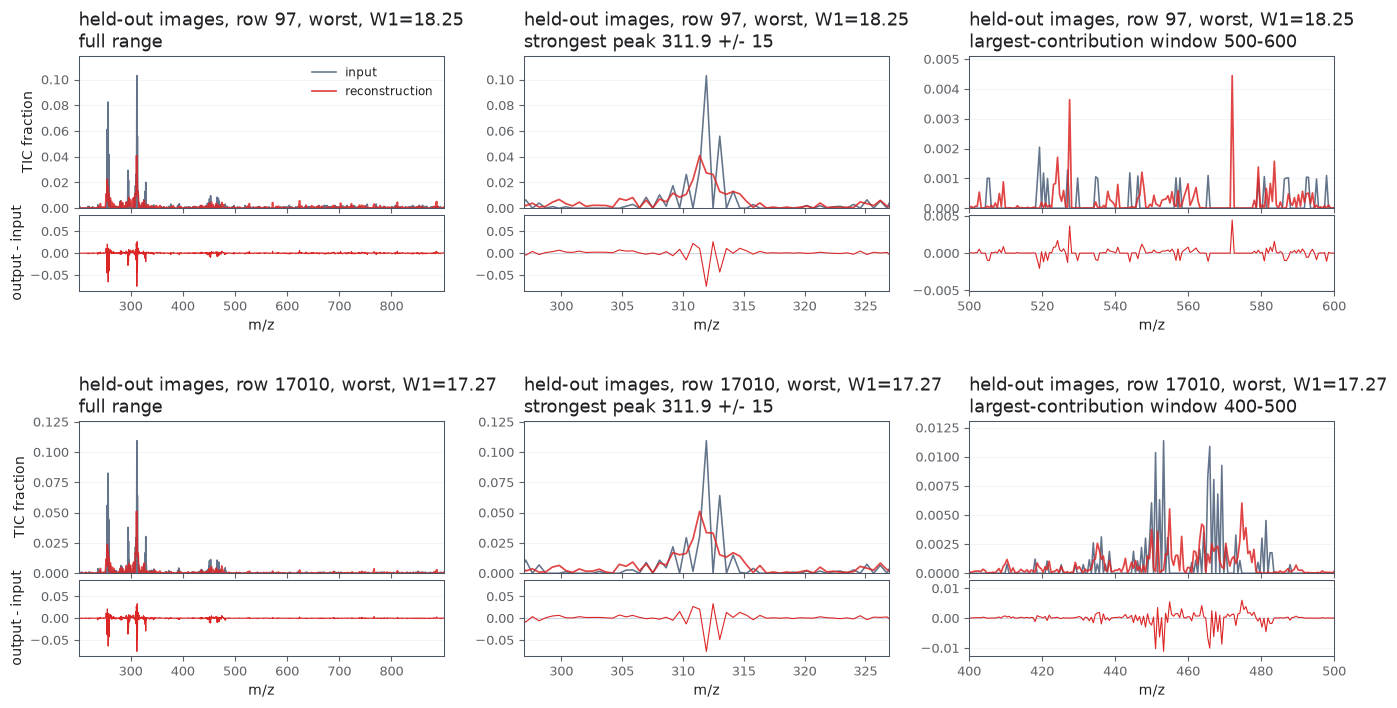

In [5]:
show_cases('worst', ascending=False)

### Remarks

- Worst cases ($W_1$ 16-43) are spectra with a few isolated strong peaks; the reconstruction is almost flat at the peak (median apex ratio 0.07) and spreads the intensity over the neighbourhood.
- The largest-contribution window of 19 of 24 worst cases is 300-400 or 400-500 m/z.

### Notes

## Fixed random spectra per population

### Methodology

#### Theoretical

Random cases show a typical reconstruction of every population.

#### Implementation

Two `fixed` cases per population of the representative model; the largest-contribution window comes from `case_windows`.

#### Figure descriptions

One figure per population, two cases each (pairs of rows). Columns: full m/z range, zoom on the strongest
input peak, zoom on the window with the largest contribution to $W_1$. Top of each pair: grey = input,
colour = reconstruction (colour = population); bottom: signed residual (reconstruction - input). Zoom
limits are set from the values inside the zoom. Titles give population, row, case kind and $W_1$.

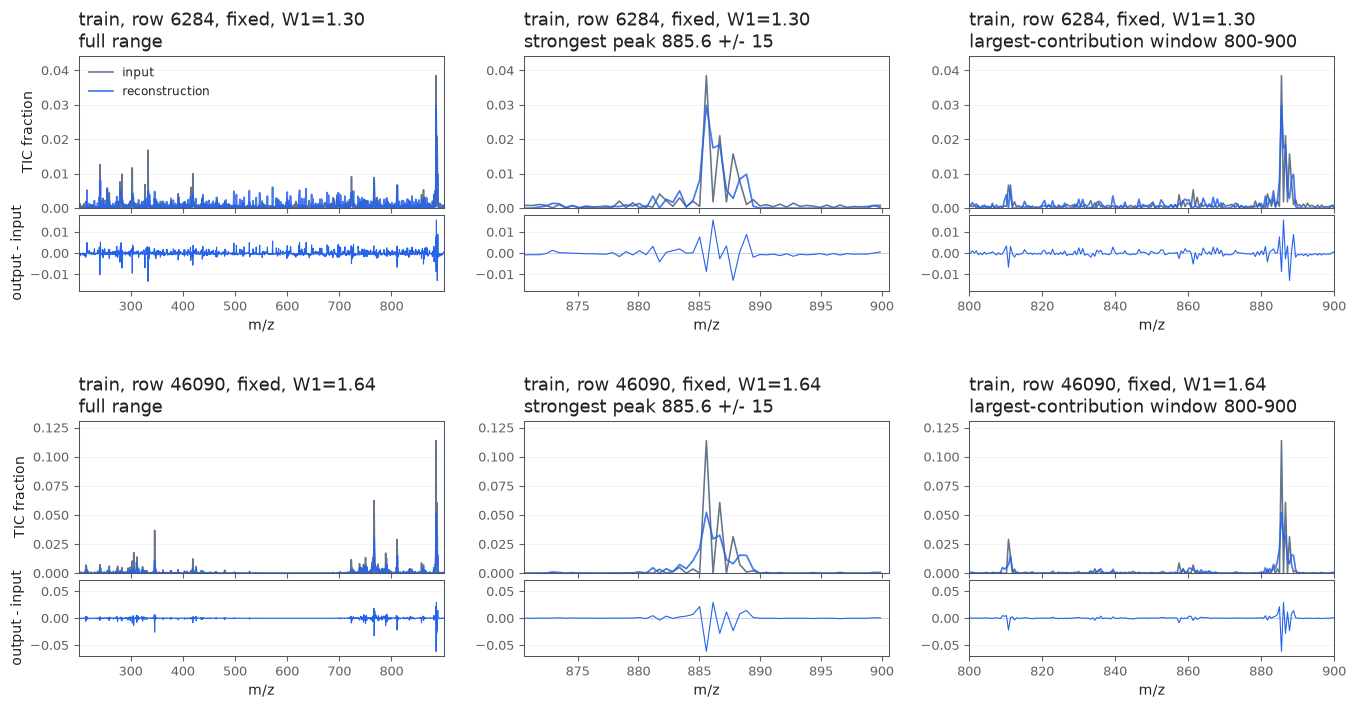

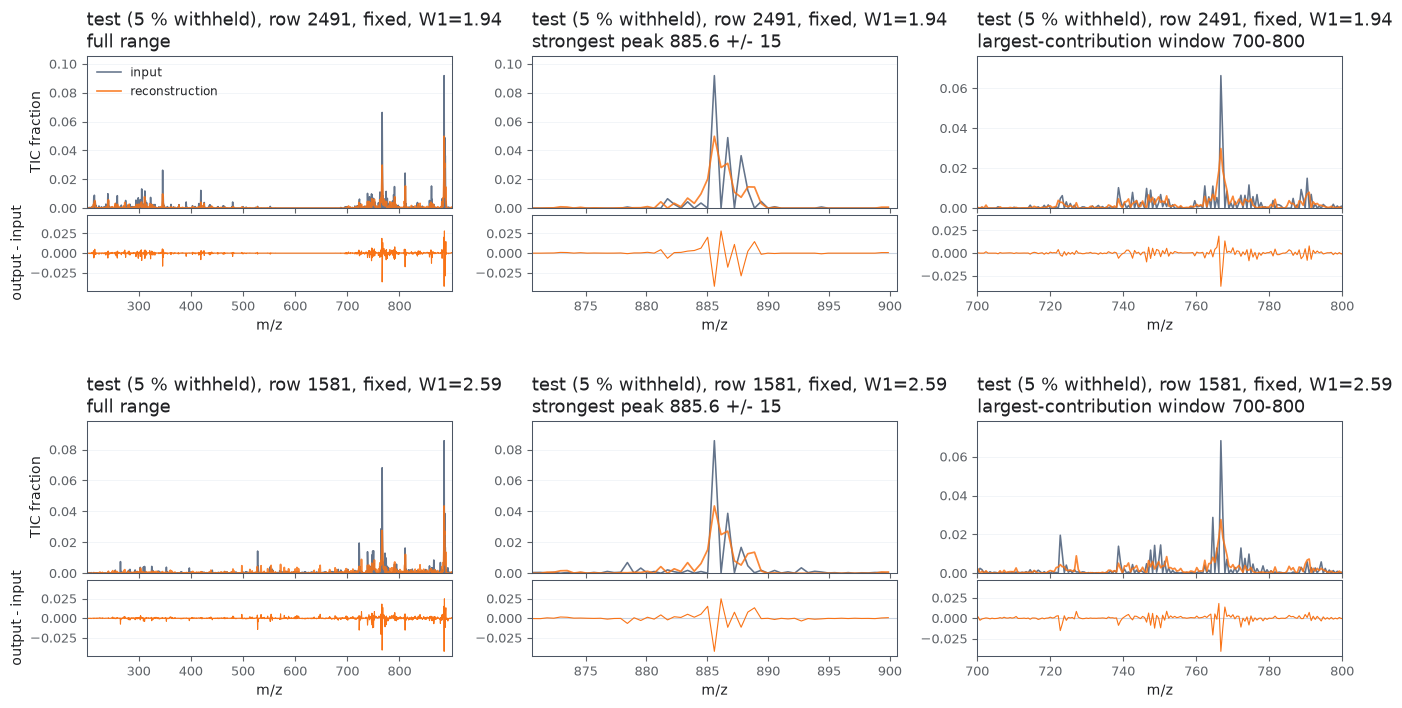

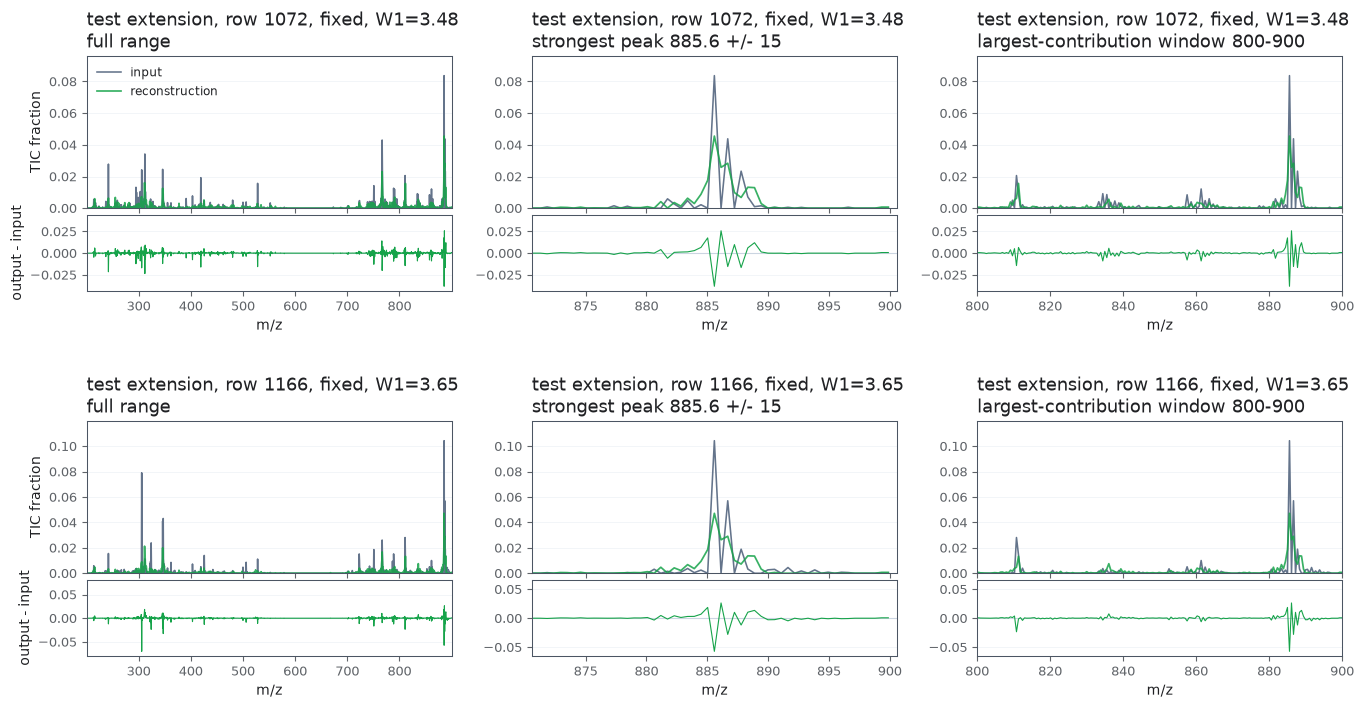

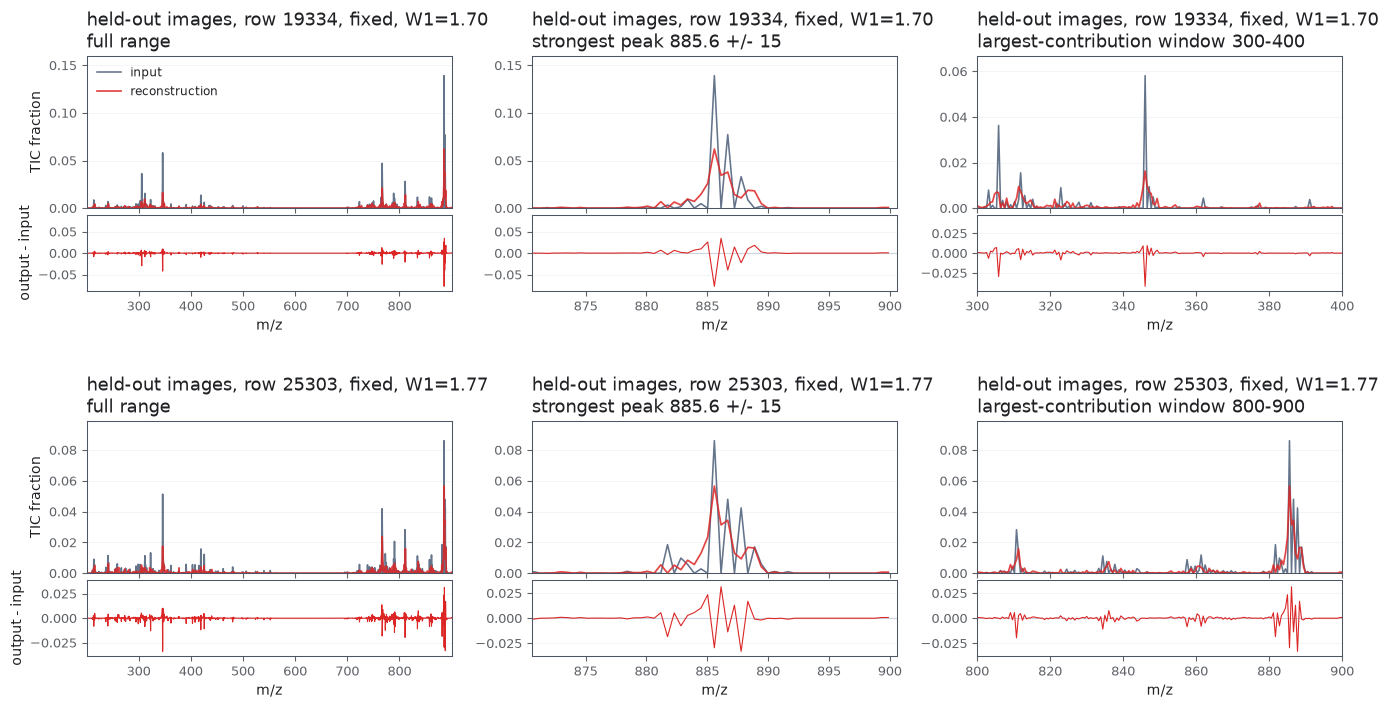

In [6]:
show_cases('fixed', ascending=True)

### Remarks

- Typical spectra: the reconstructed apex keeps about 44 % of the input apex, and the peak spans about 13 bins above 10 % of its maximum where the input spans 3 (ad-hoc count on the displayed cases within +/- 15 bins).

### Notes

## Window decomposition of the case spectra

### Methodology

#### Theoretical

The contribution of every window to the case's $W_1$ shows whether a case fails in one region or everywhere.

#### Implementation

`case_windows` holds the window arrays of every case row of every repetition; the representative model is shown.

#### Figure descriptions

Heat map: rows = case (population, kind, row), columns = windows, colour = contribution (m/z).

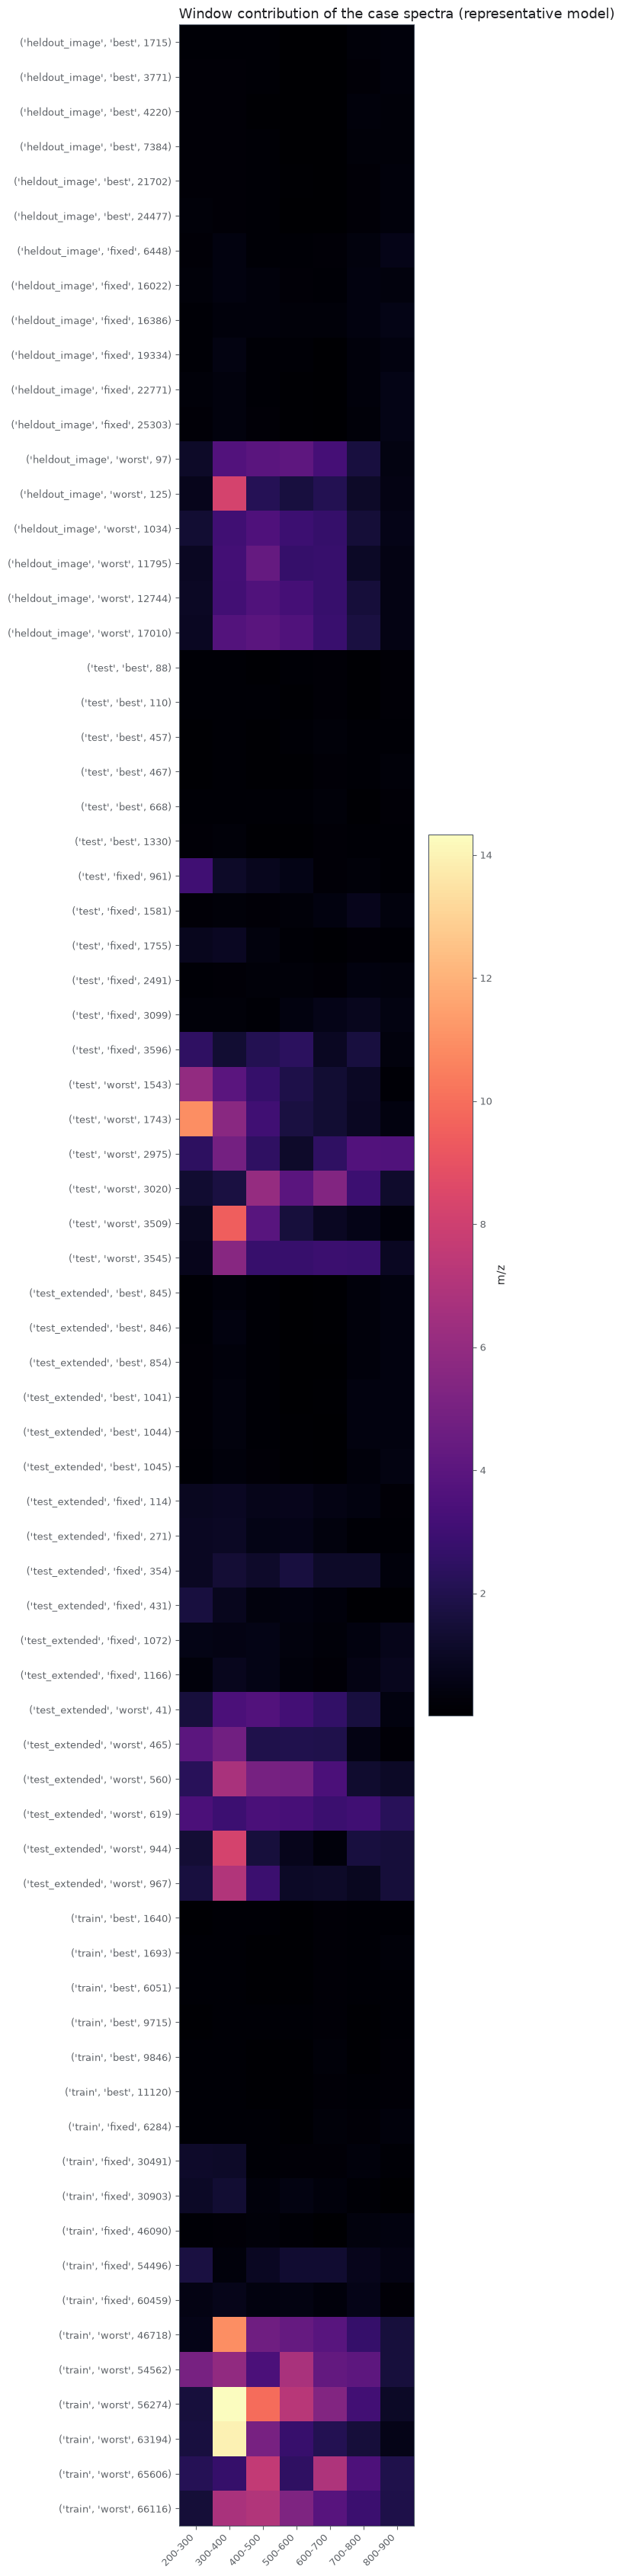

In [7]:
matrix = own_windows.pivot_table(index=['population', 'case_kind', 'row'], columns='window_label', values='contribution')
matrix = matrix[sorted(matrix.columns, key=lambda label: float(label.split('-')[0]))].dropna(axis=1, how='all')
matrix = matrix.loc[:, matrix.sum() > 0]
figures.matrix_heatmap(matrix, title='Window contribution of the case spectra (representative model)', colorbar_label='m/z', theme=theme);

### Remarks

- Worst cases pay most of their $W_1$ in one window (300-500 m/z); best cases distribute a small cost over the high-mass windows.

### Notes

## Peak position and intensity errors

### Methodology

#### Theoretical

For every detected input peak the m/z error $\hat m - m$ and the relative intensity error
$(\hat I - I) / I$ of its matched reconstruction peak are measured; `detected` marks a match above 5 % of
the input peak.

#### Implementation

`peak_matching` holds one row per peak of every case spectrum of every repetition.

#### Figure descriptions

One panel per quantity; x = population, violin = all peaks of all cases pooled over repetitions, diamonds =
repetition means. The table gives detection rate and median errors per population and case kind.

peaks  detected_fraction  median_absolute_mz_error  median_relative_intensity_error
population    case_kind                                                                                     
heldout_image best        2398             0.9971                    1.1001                          -0.1609
              fixed       2295             0.9930                    1.1001                          -0.1418
              worst       1411             0.9752                    1.6500                          -0.2182
test          best        7980             0.9764                    1.6500                           1.0238
              fixed       2250             0.9804                    1.6500                          -0.1503
              worst        766             0.9256                    1.6500                          -0.6349
test_extended best        2311             0.9957                    1.1001                          -0.1743
              fixed       2350             0.9847                    1.1001                          -0.0812
              worst       1693             0.9492                    1.6500                          -0.4181
train         best        7591             0.9788                    1.6500                           0.9831
              fixed       3090             0.9828                    1.6500                           0.0372
              worst        623             0.8090                    1.6500                          -0.8151

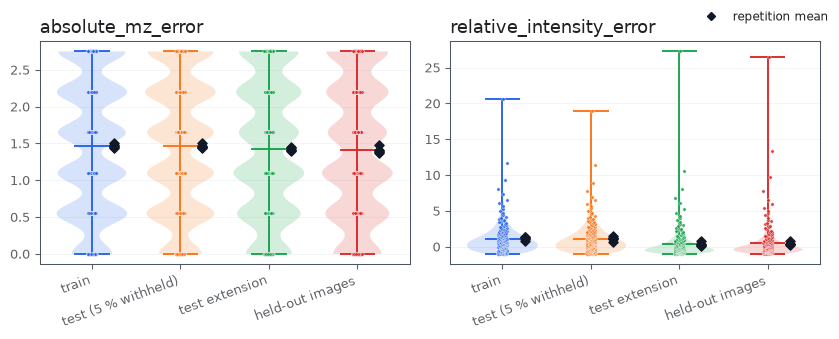

In [8]:
peaks = table('peak_matching')
peaks['absolute_mz_error'] = peaks.mz_error.abs()
means = peaks.groupby(['repetition', 'population'])[['absolute_mz_error', 'relative_intensity_error']].mean().reset_index().melt(id_vars=['repetition', 'population'], var_name='metric', value_name='mean')
figures.population_distributions(peaks, means, ['absolute_mz_error', 'relative_intensity_error'], POPULATIONS, columns=2, theme=theme);
display(peaks.groupby(['population', 'case_kind']).agg(peaks=('detected', 'size'), detected_fraction=('detected', 'mean'), median_absolute_mz_error=('absolute_mz_error', 'median'), median_relative_intensity_error=('relative_intensity_error', 'median')))

### Remarks

- 98 % of the input peaks are matched (93 % for worst cases); the median position error is 1.65 m/z = 3 bins for every case kind (hypothesis: decoder upsampling with stride 3).
- Median relative intensity error: -0.09 (fixed), -0.48 (worst), +0.74 (best; small peaks of smooth spectra are overestimated).

### Notes

## Results / Summary

### LLM

- **Observed:** the zoomed spectra show that the decoder reproduces the position of peaks within about 3 bins but not their shape: a reconstructed peak is several times wider and lower than the input peak, i.e. the model generates an envelope.
- **Observed:** worst spectra are those dominated by a few isolated strong peaks, which the envelope flattens almost completely.
- **Interpretation:** peak-level fidelity, not the global intensity distribution, is the main limitation of the reconstruction; this also explains the low per-channel image agreement in `part_1_05`.

### Person